# Netflix Data Analysis using Python

## Objective
Analyze the Netflix Movies and TV Shows dataset to discover trends in content types, release years, ratings, genres, countries, and directors using Python, Pandas, NumPy, and Matplotlib.

### Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Jupyter Notebook

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("netflix_titles.csv")

# Display first 5 rows
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
# Number of rows and columns
df.shape

(8807, 12)

In [4]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [6]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [7]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [8]:
# Check duplicate rows
df.duplicated().sum()

np.int64(0)

In [10]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
# Fill missing values
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")

# Remove rows where important values are missing
df.dropna(subset=["date_added", "rating", "duration"], inplace=True)

In [13]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [14]:
# Count Movies and TV Shows
df['type'].value_counts()

type
Movie      6126
TV Show    2664
Name: count, dtype: int64

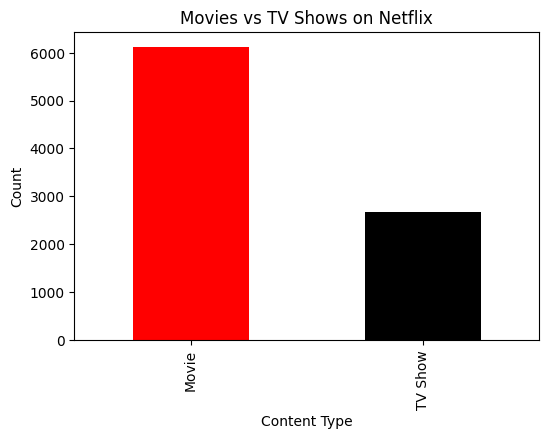

In [15]:
plt.figure(figsize=(6,4))

df['type'].value_counts().plot(
    kind='bar',
    color=['red', 'black']
)

plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Count")

plt.show()

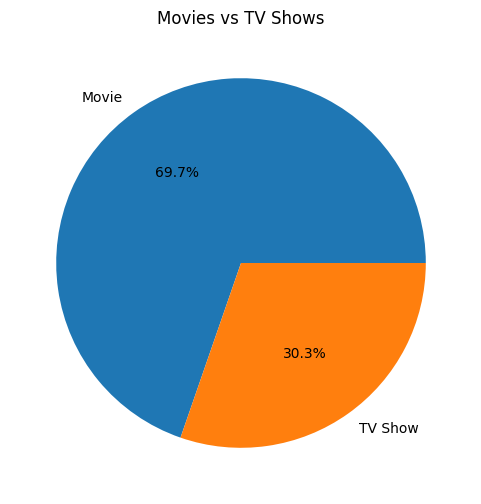

In [16]:
plt.figure(figsize=(6,6))

df['type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Movies vs TV Shows")
plt.ylabel("")

plt.show()

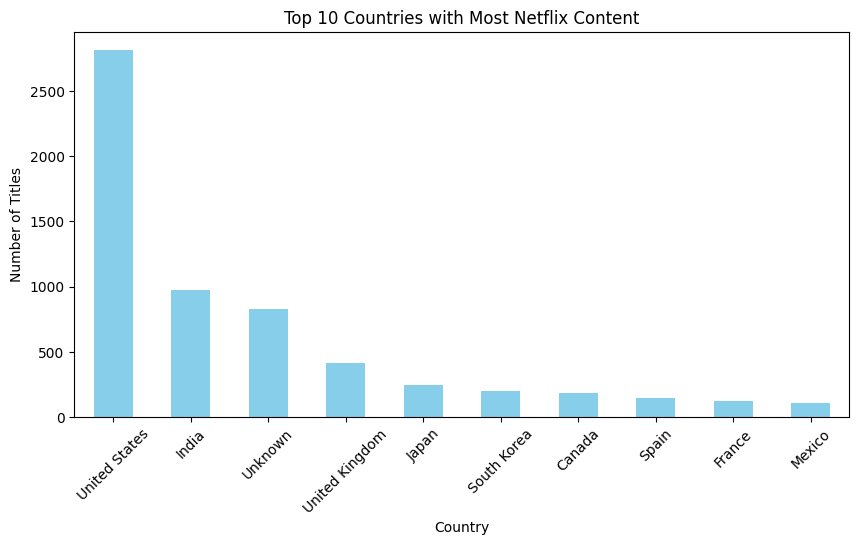

In [17]:
top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(10,5))

top_countries.plot(
    kind='bar',
    color='skyblue'
)

plt.title("Top 10 Countries with Most Netflix Content")
plt.xlabel("Country")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.show()

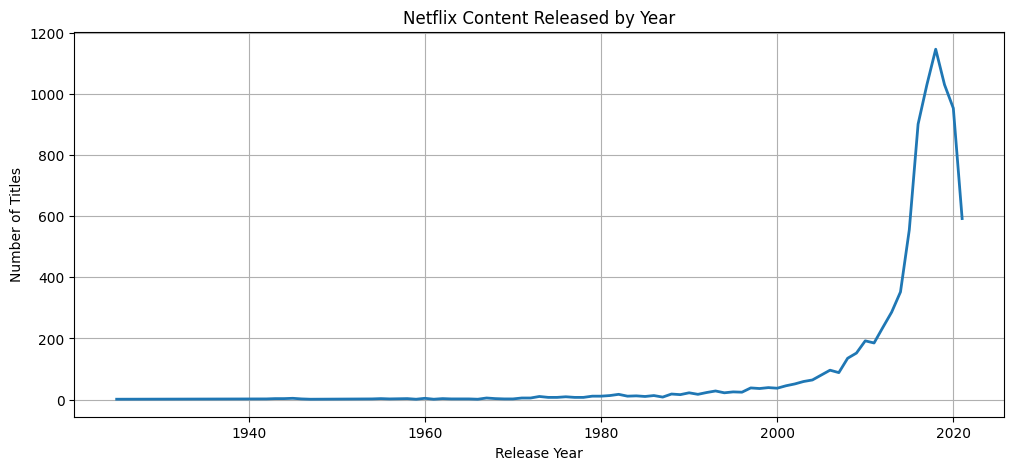

In [18]:
release_year = df['release_year'].value_counts().sort_index()

plt.figure(figsize=(12,5))

release_year.plot(
    kind='line',
    linewidth=2
)

plt.title("Netflix Content Released by Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.grid(True)

plt.show()

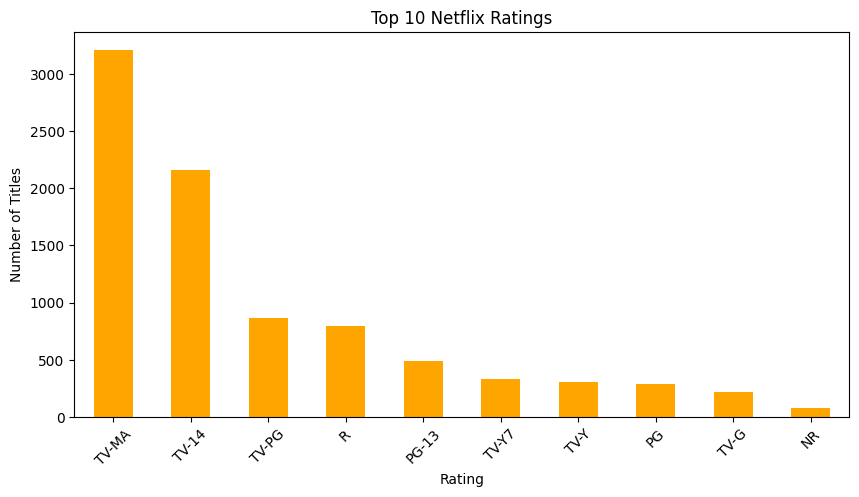

In [19]:
plt.figure(figsize=(10,5))

df['rating'].value_counts().head(10).plot(
    kind='bar',
    color='orange'
)

plt.title("Top 10 Netflix Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.show()

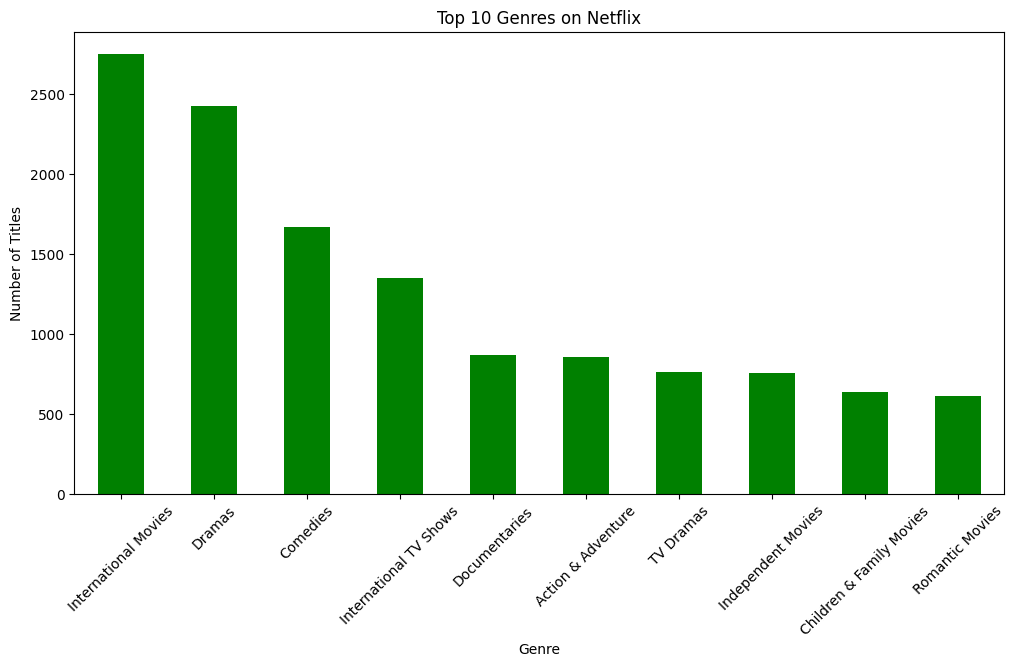

In [20]:
plt.figure(figsize=(12,6))

df['listed_in'].str.split(', ').explode().value_counts().head(10).plot(
    kind='bar',
    color='green'
)

plt.title("Top 10 Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.show()

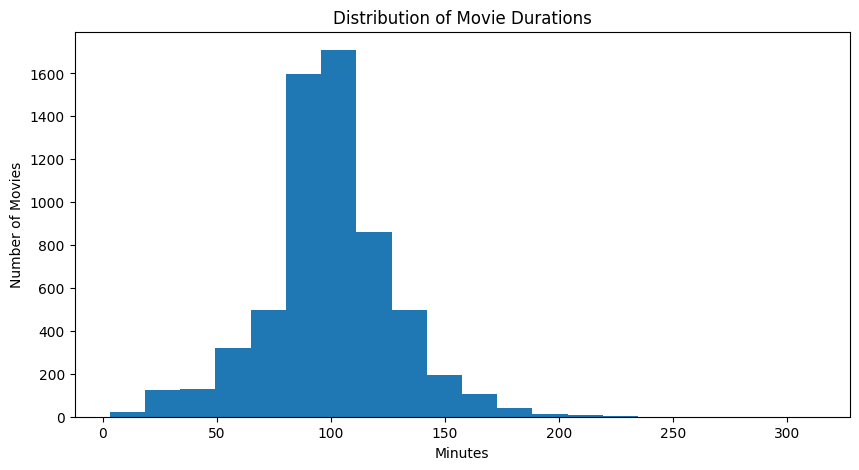

In [21]:
movies = df[df['type'] == 'Movie'].copy()

movies['duration'] = movies['duration'].str.replace(' min','')
movies['duration'] = movies['duration'].astype(int)

plt.figure(figsize=(10,5))

plt.hist(
    movies['duration'],
    bins=20
)

plt.title("Distribution of Movie Durations")
plt.xlabel("Minutes")
plt.ylabel("Number of Movies")

plt.show()

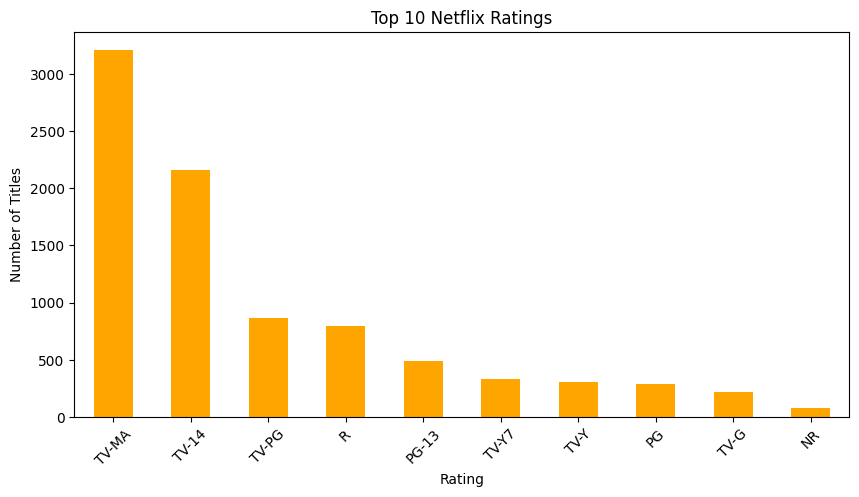

In [22]:
plt.figure(figsize=(10,5))

df['rating'].value_counts().head(10).plot(
    kind='bar',
    color='orange'
)

plt.title("Top 10 Netflix Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.show()

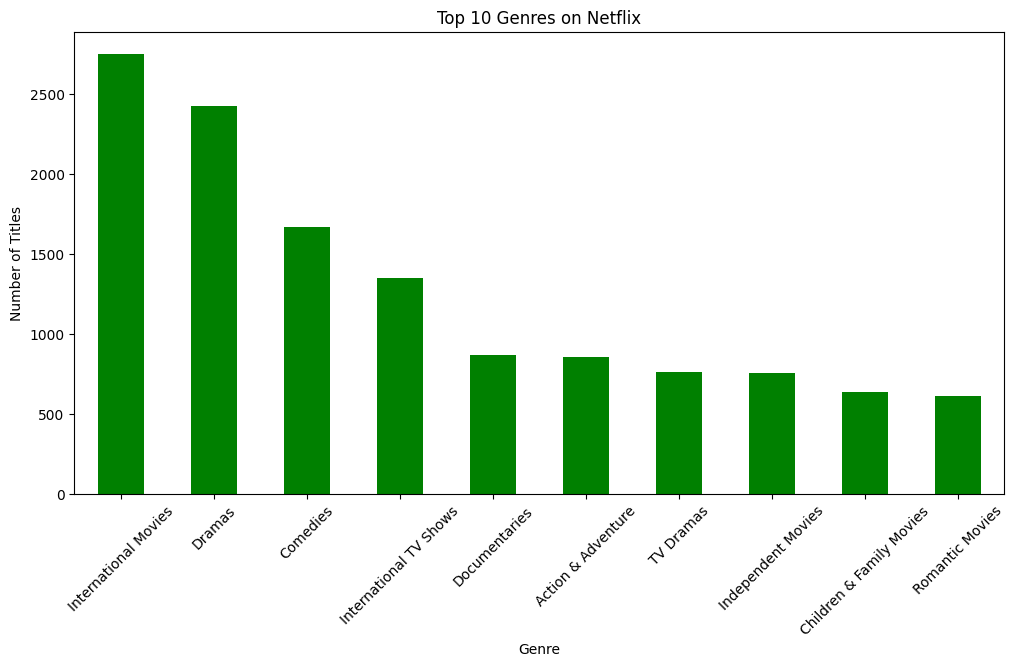

In [23]:
plt.figure(figsize=(12,6))

df['listed_in'].str.split(', ').explode().value_counts().head(10).plot(
    kind='bar',
    color='green'
)

plt.title("Top 10 Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.show()

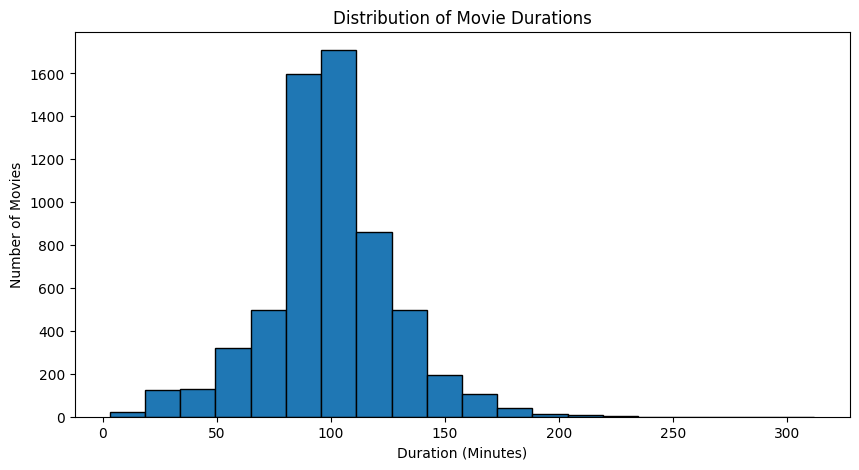

In [24]:
movies = df[df['type'] == 'Movie'].copy()

movies['duration'] = movies['duration'].str.replace(' min', '')
movies['duration'] = movies['duration'].astype(int)

plt.figure(figsize=(10,5))

plt.hist(
    movies['duration'],
    bins=20,
    edgecolor='black'
)

plt.title("Distribution of Movie Durations")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Movies")

plt.show()

In [25]:
oldest = df.sort_values('release_year').head(10)

oldest[['title', 'release_year', 'country']]

,title,release_year,country
4250,Pioneers: First Women Filmmakers*,1925,Unknown
7790,Prelude to War,1942,United States
8205,The Battle of Midway,1942,United States
8763,WWII: Report from the Aleutians,1943,United States
8739,Why We Fight: The Battle of Russia,1943,United States
8660,Undercover: How to Operate Behind Enemy Lines,1943,United States
8419,The Memphis Belle: A Story of a\nFlying Fortress,1944,United States
8640,Tunisian Victory,1944,"United States, United Kingdom"
8436,The Negro Soldier,1944,United States
7575,Nazi Concentration Camps,1945,United States


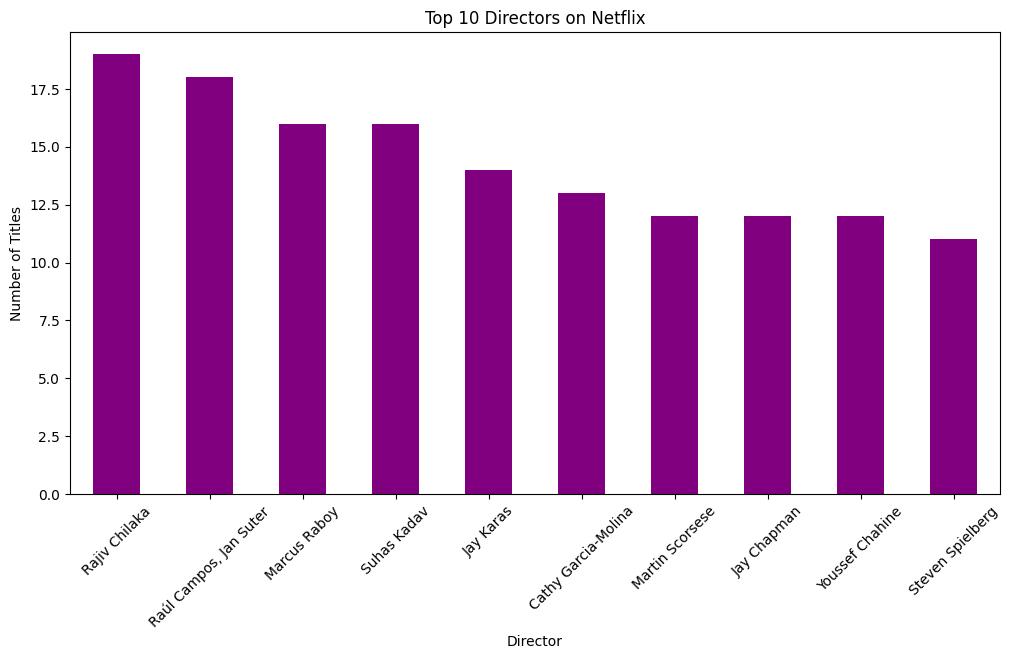

In [27]:
directors = df[df['director'] != 'Unknown']

plt.figure(figsize=(12,6))

directors['director'].value_counts().head(10).plot(
    kind='bar',
    color='purple'
)

plt.title("Top 10 Directors on Netflix")
plt.xlabel("Director")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.show()

# Key Insights

- Netflix has more Movies than TV Shows.
- The United States contributes the highest number of Netflix titles.
- Most Netflix content was released between 2017 and 2021.
- Drama and International Movies are among the most common genres.
- Rajiv Chilaka has the highest number of titles among directors.